# IDF-DS: Actuator-Aware Instantaneous Power Regression — Cleaned V2

Predict the same `power_w` target using state telemetry plus contemporaneous
PWM commands. `flight_id` is used only for grouping and is never a predictor.
This is instantaneous estimation, not future power forecasting.

In [1]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from scipy.optimize import minimize
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_squared_log_error, r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")
SEED = 42
FAST_MODE = True
TIME_SCALE_TO_SECONDS = 1.0
MIN_FLIGHT_ROWS = 100
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

DATA_PATH = Path("dataset_timeseries_cleaned_v2.csv")
if not DATA_PATH.exists():
    matches = list(Path.cwd().rglob("dataset_timeseries_cleaned_v2.csv"))
    if not matches:
        raise FileNotFoundError("dataset_timeseries_cleaned_v2.csv was not found.")
    DATA_PATH = matches[0]
print(DATA_PATH.resolve())

C:\Users\PC\Downloads\Flight\dataset_timeseries_cleaned_v2.csv


## 1. Data and PWM leakage audit

The split is flights 1–71 / 72–89 / 90–120. Voltage/current are absent from
features. Offset correlation verifies that current PWM aligns most strongly
with current power; PWM remains a strong actuator proxy rather than a
target-derived variable.

,value
rows,60454
flights,118
negative/zero target rows removed,0
short flights removed,0
missing entries,0


,value
voltage/current columns present,0.000000
overall PWM0-power correlation,0.952258
future PWM0 values already seen in development,0.999660
distinct PWM0 values,629.000000


,PWM row shift,mean within-flight correlation,median within-flight correlation
0,-3,0.799937,0.801871
1,-2,0.868865,0.869927
2,-1,0.934639,0.935458
3,0,0.977704,0.978542
4,1,0.931183,0.933515
5,2,0.862692,0.863496
6,3,0.793439,0.795026


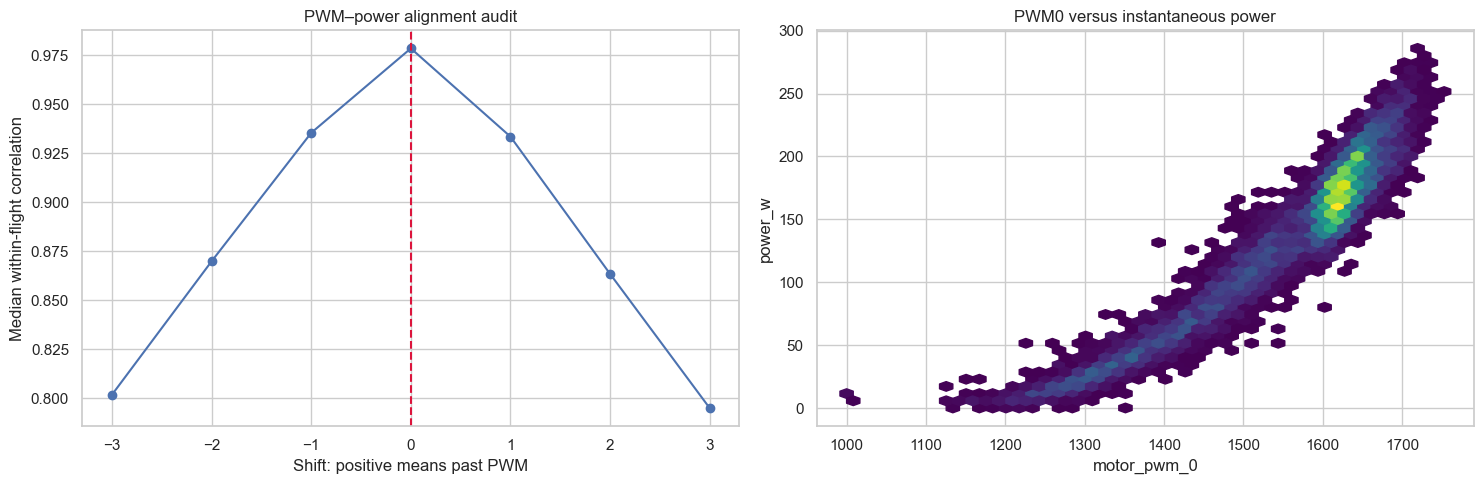

In [2]:
raw = pd.read_csv(DATA_PATH)
raw["flight_num"] = raw["flight_id"].str.extract(r"(\d+)").astype(int)
flight_sizes = raw.groupby("flight_num").size()
data = raw.loc[
    raw["flight_num"].isin(flight_sizes[flight_sizes >= MIN_FLIGHT_ROWS].index)
    & raw["power_w"].gt(0)
].sort_values(["flight_num", "t_sec"]).copy()

def campaign_from_flight(f):
    if f <= 28: return 1
    if f <= 38: return 2
    if f <= 53: return 3
    if f <= 71: return 4
    if f <= 89: return 5
    if f <= 116: return 6
    return 7

data["campaign_id"] = data["flight_num"].map(campaign_from_flight)
train_mask = data["flight_num"].le(71)
val_mask = data["flight_num"].between(72, 89)
test_mask = data["flight_num"].ge(90)

display(pd.Series({
    "rows": len(data),
    "flights": data["flight_num"].nunique(),
    "negative/zero target rows removed": int((raw["power_w"] <= 0).sum()),
    "short flights removed": int((flight_sizes < MIN_FLIGHT_ROWS).sum()),
    "missing entries": int(data.isna().sum().sum()),
}).to_frame("value"))

ordered = data.sort_values(["flight_num", "t_sec"])
grouped = ordered.groupby("flight_num", sort=False)
offset_rows = []
for shift in range(-3, 4):
    shifted = grouped["motor_pwm_0"].shift(shift)
    correlations = []
    for flight, z in ordered.assign(shifted_pwm=shifted).groupby("flight_num"):
        correlations.append(z[["power_w", "shifted_pwm"]].corr().iloc[0, 1])
    offset_rows.append({
        "PWM row shift": shift,
        "mean within-flight correlation": np.nanmean(correlations),
        "median within-flight correlation": np.nanmedian(correlations),
    })
offset_audit = pd.DataFrame(offset_rows)

development_pwm = set(data.loc[train_mask | val_mask, "motor_pwm_0"].dropna().unique())
audit = pd.Series({
    "voltage/current columns present": sum(
        any(s in c.lower() for s in ["voltage", "current"]) for c in data.columns
    ),
    "overall PWM0-power correlation": data[["motor_pwm_0", "power_w"]].corr().iloc[0, 1],
    "future PWM0 values already seen in development": (
        data.loc[test_mask, "motor_pwm_0"].isin(development_pwm).mean()
    ),
    "distinct PWM0 values": data["motor_pwm_0"].nunique(),
})
display(audit.to_frame("value"))
display(offset_audit)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(offset_audit["PWM row shift"],
             offset_audit["median within-flight correlation"], marker="o")
axes[0].axvline(0, color="crimson", linestyle="--")
axes[0].set_title("PWM–power alignment audit")
axes[0].set_xlabel("Shift: positive means past PWM")
axes[0].set_ylabel("Median within-flight correlation")
sample = data.sample(min(10_000, len(data)), random_state=SEED)
axes[1].hexbin(sample["motor_pwm_0"], sample["power_w"], gridsize=45,
               cmap="viridis", mincnt=1)
axes[1].set_title("PWM0 versus instantaneous power")
axes[1].set_xlabel("motor_pwm_0")
axes[1].set_ylabel("power_w")
plt.tight_layout()
plt.show()

## 2. Features and baselines

State features are augmented with four PWM channels, consistent actuator
aggregates, and causal PWM lags. Assertions explicitly exclude identifiers.

In [3]:
def engineer_features(frame):
    d = frame.sort_values(["flight_num", "t_sec"]).copy()
    d["time_s"] = d["t_sec"] * TIME_SCALE_TO_SECONDS
    pwm = [f"motor_pwm_{i}" for i in range(4)]
    d["actuator_mean_4"] = d[pwm].mean(axis=1)
    d["actuator_std_4"] = d[pwm].std(axis=1, ddof=1)
    d["actuator_range_4"] = d[pwm].max(axis=1) - d[pwm].min(axis=1)
    d["pwm0_norm"] = (d["motor_pwm_0"] - 1500.0) / 500.0
    d["pwm0_norm_sq"] = d["pwm0_norm"] ** 2
    d["pwm0_norm_cube"] = d["pwm0_norm"] ** 3
    d["ground_speed_3d"] = np.sqrt(d["pos_vx"]**2 + d["pos_vy"]**2 + d["pos_vz"]**2)
    d["accel_magnitude"] = np.sqrt(d["pos_ax"]**2 + d["pos_ay"]**2 + d["pos_az"]**2)
    d["dynamic_pressure"] = 0.5 * d["air_rho"] * d["true_airspeed"]**2
    d["airspeed_cubed"] = d["true_airspeed"]**3
    d["climb_positive"] = d["climb_rate"].clip(lower=0)
    d["sink_positive"] = (-d["climb_rate"]).clip(lower=0)
    d["headwind_x_airspeed"] = d["headwind_component"] * d["true_airspeed"]
    d["load_factor_proxy"] = 1 / np.cos(d["tilt_angle"].clip(-1.2, 1.2))
    for a in ["roll", "pitch"]:
        d[f"sin_{a}"] = np.sin(d[a])
        d[f"cos_{a}"] = np.cos(d[a])
    g = d.groupby("flight_num", sort=False)
    dt = g["time_s"].diff().replace(0, np.nan)
    for c in ["true_airspeed", "climb_rate", "pitch",
              "speed_horizontal", "motor_pwm_0"]:
        d[f"{c}_lag1"] = g[c].shift(1)
        d[f"d_{c}_dt"] = g[c].diff() / dt
        d[f"{c}_roll3_past"] = g[c].transform(
            lambda s: s.shift(1).rolling(3, min_periods=1).mean()
        )
    return d.replace([np.inf, -np.inf], np.nan)

data = engineer_features(data)
state_features = [
    "pos_vx", "pos_vy", "pos_ax", "pos_ay", "pos_az",
    "speed_horizontal", "climb_rate", "roll", "pitch", "tilt_angle",
    "headwind_component", "air_rho", "air_ambient_temperature",
    "true_airspeed", "wind_north", "wind_east",
    "ground_speed_3d", "accel_magnitude", "dynamic_pressure",
    "airspeed_cubed", "climb_positive", "sink_positive",
    "headwind_x_airspeed", "load_factor_proxy",
    "sin_roll", "cos_roll", "sin_pitch", "cos_pitch",
    "true_airspeed_lag1", "d_true_airspeed_dt", "true_airspeed_roll3_past",
    "climb_rate_lag1", "d_climb_rate_dt", "climb_rate_roll3_past",
    "pitch_lag1", "d_pitch_dt", "pitch_roll3_past",
    "speed_horizontal_lag1", "d_speed_horizontal_dt",
    "speed_horizontal_roll3_past",
]
pwm_features = [
    "motor_pwm_0", "motor_pwm_1", "motor_pwm_2", "motor_pwm_3",
    "actuator_mean_4", "actuator_std_4", "actuator_range_4",
    "pwm0_norm", "pwm0_norm_sq", "pwm0_norm_cube",
    "motor_pwm_0_lag1", "d_motor_pwm_0_dt", "motor_pwm_0_roll3_past",
]
features = state_features + pwm_features

X_train, y_train = data.loc[train_mask, features], data.loc[train_mask, "power_w"]
X_val, y_val = data.loc[val_mask, features], data.loc[val_mask, "power_w"]
X_test, y_test = data.loc[test_mask, features], data.loc[test_mask, "power_w"]
g_train = data.loc[train_mask, "flight_num"]
g_val = data.loc[val_mask, "flight_num"]
g_test = data.loc[test_mask, "flight_num"]
assert "flight_id" not in features
assert "flight_num" not in features
assert "campaign_id" not in features
print("Features:", len(features), "| PWM/actuator features:", len(pwm_features))
print("flight_id used as predictor:", "flight_id" in features)

def clip_pred(p):
    return np.clip(np.asarray(p, dtype=float), 0, None)

def metrics(y, p):
    p = clip_pred(p)
    return {
        "RMSE_W": mean_squared_error(y, p) ** 0.5,
        "MAE_W": mean_absolute_error(y, p),
        "RMSLE": mean_squared_log_error(y, p) ** 0.5,
        "R2": r2_score(y, p),
    }

def extended_metrics(y, p, groups):
    result = metrics(y, p)
    frame = pd.DataFrame({"y": np.asarray(y), "p": clip_pred(p),
                          "group": np.asarray(groups)})
    per_flight, dy, dp = [], [], []
    for _, z in frame.groupby("group", sort=False):
        per_flight.append(metrics(z["y"], z["p"]))
        dy.extend(np.diff(z["y"]))
        dp.extend(np.diff(z["p"]))
    macro = pd.DataFrame(per_flight).mean()
    result.update({f"macro_{k}": v for k, v in macro.items()})
    result["delta_R2"] = r2_score(dy, dp)
    return result

def equal_flight_weights(groups):
    counts = pd.Series(groups).value_counts()
    w = pd.Series(groups).map(1 / counts).to_numpy(copy=True)
    return w / w.mean()

baseline_specs = {
    "Mean": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyRegressor(strategy="mean")),
    ]),
    "PWM0 OLS": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LinearRegression()),
    ]),
    "Multivariate Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", RobustScaler(quantile_range=(5, 95))),
        ("model", Ridge(alpha=10)),
    ]),
    "Extra Trees raw-target": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=250, min_samples_leaf=10,
            max_features=0.7, n_jobs=-1, random_state=SEED
        )),
    ]),
}
baseline_rows, baseline_val_predictions = [], {}
for name, model in baseline_specs.items():
    fs = ["motor_pwm_0"] if name == "PWM0 OLS" else features
    kwargs = {}
    if name not in ["Mean", "PWM0 OLS"]:
        kwargs["model__sample_weight"] = equal_flight_weights(g_train)
    model.fit(X_train[fs], y_train, **kwargs)
    pred = clip_pred(model.predict(X_val[fs]))
    baseline_val_predictions[name] = pred
    baseline_rows.append({"model": name, **extended_metrics(y_val, pred, g_val)})
baseline_results = pd.DataFrame(baseline_rows).sort_values("RMSLE")
display(baseline_results)

Features: 53 | PWM/actuator features: 13
flight_id used as predictor: False


,model,RMSE_W,MAE_W,RMSLE,R2,macro_RMSE_W,macro_MAE_W,macro_RMSLE,macro_R2,delta_R2
3,Extra Trees raw-target,12.543400,9.884370,0.127445,0.960303,11.768676,9.813456,0.120329,0.956224,8.622396e-01
2,Multivariate Ridge,13.586433,10.945981,0.193045,0.953426,12.771489,10.837019,0.184524,0.947415,8.484816e-01
1,PWM0 OLS,15.304538,12.237441,0.450403,0.940902,14.862014,12.236053,0.441342,0.937662,8.330278e-01
0,Mean,62.985101,53.101635,0.788507,-0.000939,62.979736,53.302528,0.785006,-0.035222,-2.830154e-07


## 3. RMSLE-optimized geometric ensemble

Five regularized Extra Trees variants learn `log1p(power)`. Non-negative
geometric weights are fitted only on validation campaign predictions.

In [4]:
configs = [
    {"name": "ET leaf10 mf0.60", "leaf": 10, "mf": 0.60},
    {"name": "ET leaf20 mf0.60", "leaf": 20, "mf": 0.60},
    {"name": "ET leaf20 mf0.80", "leaf": 20, "mf": 0.80},
    {"name": "ET leaf30 mf0.60", "leaf": 30, "mf": 0.60},
    {"name": "ET leaf40 mf0.60", "leaf": 40, "mf": 0.60},
]

def make_model(config):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=200 if FAST_MODE else 700,
            min_samples_leaf=config["leaf"],
            max_features=config["mf"],
            n_jobs=-1,
            random_state=SEED,
        )),
    ])

val_log_matrix, config_rows = [], []
for config in configs:
    t0 = time.perf_counter()
    model = make_model(config)
    model.fit(
        X_train, np.log1p(y_train),
        model__sample_weight=equal_flight_weights(g_train)
    )
    log_pred = model.predict(X_val)
    pred = clip_pred(np.expm1(log_pred))
    val_log_matrix.append(log_pred)
    config_rows.append({
        "model": config["name"],
        "fit_seconds": time.perf_counter() - t0,
        **extended_metrics(y_val, pred, g_val),
    })
val_log_matrix = np.column_stack(val_log_matrix)
config_results = pd.DataFrame(config_rows).sort_values("RMSLE")
display(config_results)

log_y_val = np.log1p(y_val.to_numpy())
def objective(w):
    return np.sqrt(np.mean((log_y_val - val_log_matrix @ w) ** 2))

weight_fit = minimize(
    objective,
    np.full(len(configs), 1 / len(configs)),
    method="SLSQP",
    bounds=[(0, 1)] * len(configs),
    constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
    options={"maxiter": 2000, "ftol": 1e-13},
)
if not weight_fit.success:
    raise RuntimeError(weight_fit.message)
blend_weights = weight_fit.x
display(pd.DataFrame({
    "model": [c["name"] for c in configs],
    "geometric_weight": blend_weights,
}))
validation_blend = clip_pred(np.expm1(val_log_matrix @ blend_weights))
print("Validation blend:", extended_metrics(y_val, validation_blend, g_val))

,model,fit_seconds,RMSE_W,MAE_W,RMSLE,R2,macro_RMSE_W,macro_MAE_W,macro_RMSLE,macro_R2,delta_R2
2,ET leaf20 mf0.80,3.062684,12.413755,9.766671,0.118282,0.961119,11.715461,9.735252,0.112898,0.957943,0.862523
0,ET leaf10 mf0.60,2.937718,12.343588,9.701212,0.118328,0.961557,11.633837,9.659907,0.112513,0.958171,0.863199
1,ET leaf20 mf0.60,2.402660,12.351704,9.721243,0.118621,0.961507,11.658821,9.697948,0.113314,0.958519,0.863905
3,ET leaf30 mf0.60,2.162627,12.379652,9.747522,0.118777,0.961332,11.694292,9.732807,0.113602,0.958534,0.864788
4,ET leaf40 mf0.60,2.049679,12.387473,9.754846,0.119359,0.961283,11.692145,9.744320,0.114391,0.958570,0.865090


,model,geometric_weight
0,ET leaf10 mf0.60,4.407657e-01
1,ET leaf20 mf0.60,0.000000e+00
2,ET leaf20 mf0.80,4.470175e-01
3,ET leaf30 mf0.60,1.122169e-01
4,ET leaf40 mf0.60,1.647526e-18


Validation blend: {'RMSE_W': 12.359538652803236, 'MAE_W': 9.722739878439913, 'RMSLE': 0.11814294829858217, 'R2': 0.961457821749191, 'macro_RMSE_W': 11.65629403987861, 'macro_MAE_W': 9.688873082955546, 'macro_RMSLE': 0.11257470480601918, 'macro_R2': 0.9582369969467628, 'delta_R2': 0.8640253355686173}


## 4. Frozen future-campaign evaluation and diagnostics

In [5]:
development_mask = train_mask | val_mask
X_dev = data.loc[development_mask, features]
y_dev = data.loc[development_mask, "power_w"]
g_dev = data.loc[development_mask, "flight_num"]

test_log_matrix, final_models = [], {}
for config in configs:
    model = make_model(config)
    model.fit(
        X_dev, np.log1p(y_dev),
        model__sample_weight=equal_flight_weights(g_dev),
    )
    test_log_matrix.append(model.predict(X_test))
    final_models[config["name"]] = model
test_log_matrix = np.column_stack(test_log_matrix)
final_prediction = clip_pred(np.expm1(test_log_matrix @ blend_weights))
final_metrics = extended_metrics(y_test, final_prediction, g_test)
display(pd.DataFrame([{"model": "PWM log-geometric ensemble", **final_metrics}]))

,model,RMSE_W,MAE_W,RMSLE,R2,macro_RMSE_W,macro_MAE_W,macro_RMSLE,macro_R2,delta_R2
0,PWM log-geometric ensemble,17.769863,13.798736,0.178897,0.925276,16.097088,13.753475,0.167065,0.920577,0.856089


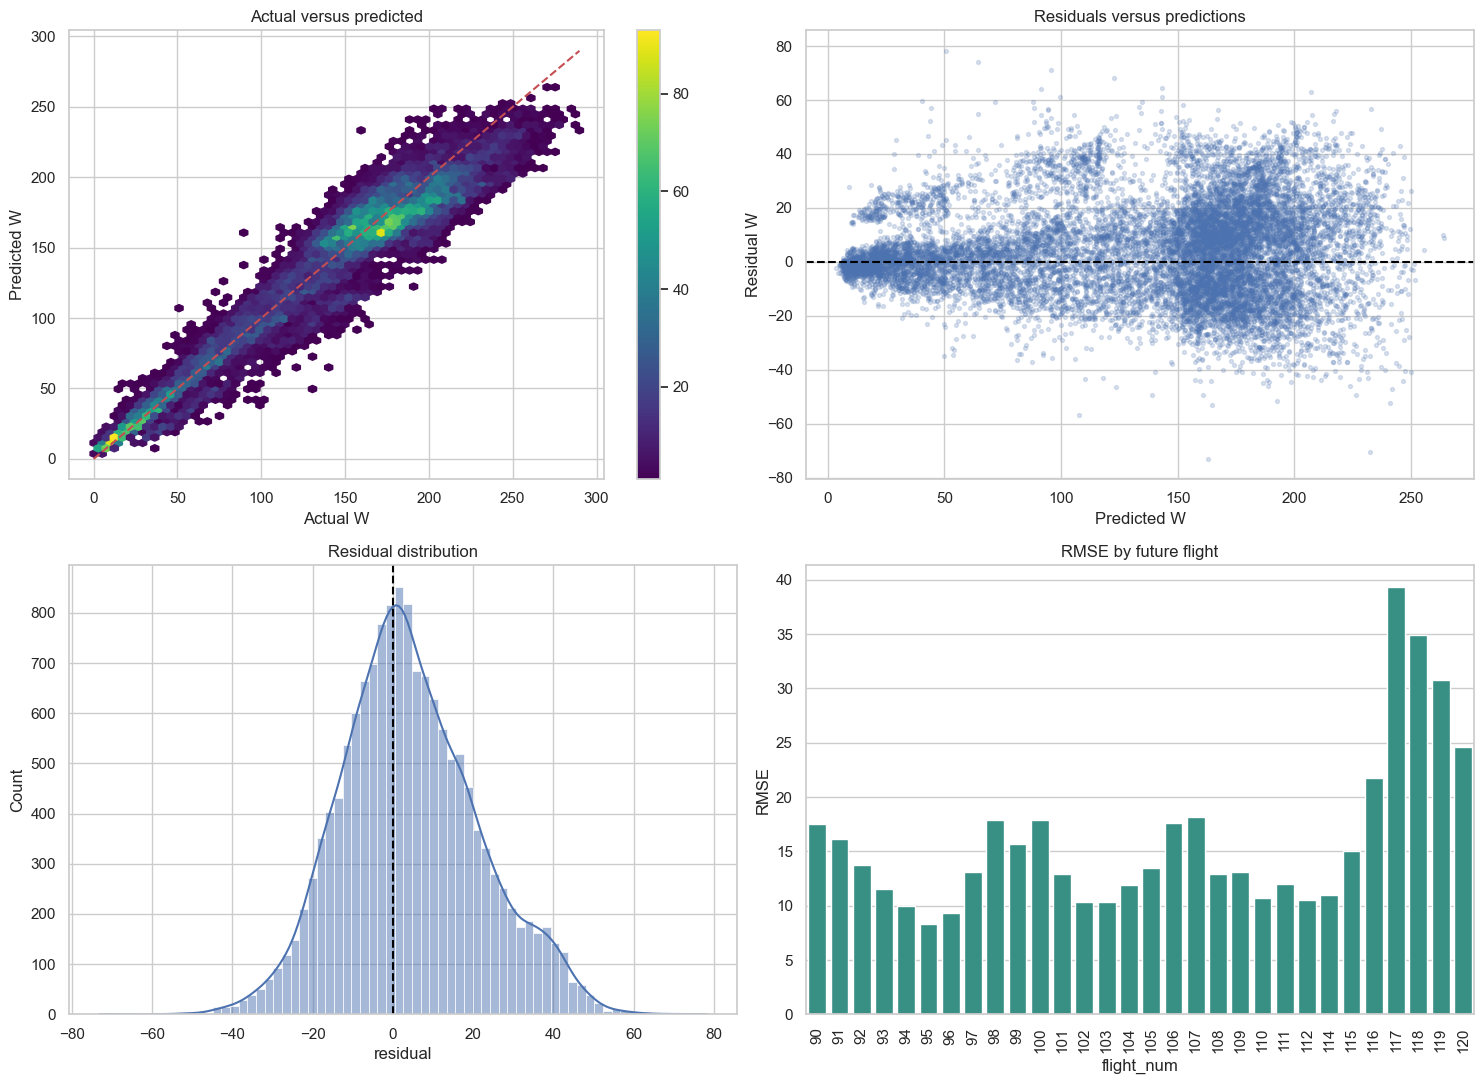

In [6]:
test_diag = data.loc[test_mask, ["flight_num", "time_s", "power_w"]].copy()
test_diag["prediction"] = final_prediction
test_diag["residual"] = test_diag["power_w"] - test_diag["prediction"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
hb = axes[0, 0].hexbin(
    test_diag["power_w"], test_diag["prediction"],
    gridsize=60, cmap="viridis", mincnt=1
)
lim = [0, max(test_diag["power_w"].max(), test_diag["prediction"].max())]
axes[0, 0].plot(lim, lim, "r--")
axes[0, 0].set(title="Actual versus predicted", xlabel="Actual W", ylabel="Predicted W")
fig.colorbar(hb, ax=axes[0, 0])
axes[0, 1].scatter(test_diag["prediction"], test_diag["residual"],
                   s=8, alpha=0.2)
axes[0, 1].axhline(0, color="black", linestyle="--")
axes[0, 1].set(title="Residuals versus predictions",
               xlabel="Predicted W", ylabel="Residual W")
sns.histplot(test_diag["residual"], bins=70, kde=True, ax=axes[1, 0])
axes[1, 0].axvline(0, color="black", linestyle="--")
axes[1, 0].set_title("Residual distribution")
flight_rmse = test_diag.groupby("flight_num").apply(
    lambda z: mean_squared_error(z["power_w"], z["prediction"]) ** 0.5,
    include_groups=False,
).rename("RMSE").reset_index()
sns.barplot(data=flight_rmse, x="flight_num", y="RMSE", ax=axes[1, 1],
            color="#2a9d8f")
axes[1, 1].tick_params(axis="x", rotation=90)
axes[1, 1].set_title("RMSE by future flight")
plt.tight_layout()
plt.show()

## 5. Conclusion

PWM-aware performance is reported separately from state-only inference because
actuator commands provide a near-direct proxy for electrical demand.

In [7]:
display(Markdown(
    f"""
## Executed PWM-aware summary

- **Target:** `power_w`
- **PWM available at inference:** yes
- **Future-campaign RMSE:** {final_metrics['RMSE_W']:.2f} W
- **Future-campaign MAE:** {final_metrics['MAE_W']:.2f} W
- **Future-campaign RMSLE:** **{final_metrics['RMSLE']:.4f}**
- **Global R²:** {final_metrics['R2']:.4f}
- **Macro-flight R²:** {final_metrics['macro_R2']:.4f}
- **First-difference R²:** {final_metrics['delta_R2']:.4f}

The ensemble weights were learned only from validation flights 72–89 and were
frozen before future campaigns 90–120 were evaluated.
"""
))

previous_pwm_rmsle = 0.1789
new_pwm_rmsle = final_metrics["RMSLE"]
pwm_comparison = pd.DataFrame([{
    "model": "PWM-aware",
    "previous_RMSLE": previous_pwm_rmsle,
    "cleaned_V2_RMSLE": new_pwm_rmsle,
    "absolute_change": new_pwm_rmsle - previous_pwm_rmsle,
    "percent_change": 100 * (new_pwm_rmsle / previous_pwm_rmsle - 1),
    "RMSLE_decreased_at_4dp": round(new_pwm_rmsle, 4) < round(previous_pwm_rmsle, 4),
}])
display(pwm_comparison)


## Executed PWM-aware summary

- **Target:** `power_w`
- **PWM available at inference:** yes
- **Future-campaign RMSE:** 17.77 W
- **Future-campaign MAE:** 13.80 W
- **Future-campaign RMSLE:** **0.1789**
- **Global R²:** 0.9253
- **Macro-flight R²:** 0.9206
- **First-difference R²:** 0.8561

The ensemble weights were learned only from validation flights 72–89 and were
frozen before future campaigns 90–120 were evaluated.


,model,previous_RMSLE,cleaned_V2_RMSLE,absolute_change,percent_change,RMSLE_decreased_at_4dp
0,PWM-aware,0.1789,0.178897,-0.000003,-0.001635,False
